**Phase 1: Environment Setup & Data Loading**

In [5]:
# Install & Import Librarires
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
# Load The Dataset
df = pd.read_csv('train.csv')
print("--- Dataset Preview ---")
print(df.head())
print(f"Dataset Size: {df.shape}")

--- Dataset Preview ---
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region     

**Phase 2: Data Cleaning**

In [11]:
# 1. Convert Order Date to Python Datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

# 2. Check for missing values (Machine Learning models hate missing values!)
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Create a clean subset for our RFM model
df_clean = df[['Customer ID', 'Order Date', 'Sales']]
print("\nData is ready for RFM analysis.")


Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Data is ready for RFM analysis.


**Phase 3: Feature Engineering (Creating the RFM Table)**

In [12]:
# 1. Set the "Analysis Date"
# We pretend we are doing this analysis the day after the last recorded sale in the dataset.
analysis_date = df['Order Date'].max() + dt.timedelta(days=1)

# 2. Group by Customer ID to calculate R, F, and M
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (analysis_date - x.max()).days, # Recency: How many days ago was the last order?
    'Customer ID': 'count',                                # Frequency: How many items did they buy?
    'Sales': 'sum'                                         # Monetary: How much total money did they spend?
})

# 3. Rename columns to be clear
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 4. Preview your new table
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
AA-10315         185         11  5563.560
AA-10375          20         15  1056.390
AA-10480         260         12  1790.512
AA-10645          56         18  5086.935
AB-10015         416          6   886.156


**Phase 4: Data Preprocessing (Handling Outliers)**

In [13]:
# Function to cap outliers using the IQR method
def cap_outliers(dataframe, column):
    Q1 = dataframe[column].quantile(0.05) # Lower limit (5th percentile)
    Q3 = dataframe[column].quantile(0.95) # Upper limit (95th percentile)
    IQR = Q3 - Q1
    
    # Define the limit (we are being generous with 1.5x IQR)
    upper_limit = Q3 + 1.5 * IQR
    
    # Cap the values
    dataframe[column] = dataframe[column].clip(upper=upper_limit)
    print(f"Capped outliers for {column} at {upper_limit:.2f}")

# Apply it to Frequency and Monetary
cap_outliers(rfm, 'Frequency')
cap_outliers(rfm, 'Monetary')

# Check the new stats
print(rfm.describe())

Capped outliers for Frequency at 54.00
Capped outliers for Monetary at 19114.34
           Recency   Frequency      Monetary
count   793.000000  793.000000    793.000000
mean    149.286255   12.358134   2844.398583
std     187.081466    6.162600   2565.150015
min       1.000000    1.000000      4.833000
25%      31.000000    8.000000   1081.466000
50%      76.000000   11.000000   2215.002000
75%     185.000000   16.000000   3670.258000
max    1166.000000   35.000000  19114.343800


**Phase 5: Machine Learning (Training the Brain)**

In [16]:
# Create the new feature: Monetary / Frequency
rfm['Avg_Order_Value'] = rfm['Monetary'] / rfm['Frequency']

# Check if the column was added
print(rfm.head())

             Recency  Frequency  Monetary  Avg_Order_Value
Customer ID                                               
AA-10315         185         11  5563.560       505.778182
AA-10375          20         15  1056.390        70.426000
AA-10480         260         12  1790.512       149.209333
AA-10645          56         18  5086.935       282.607500
AB-10015         416          6   886.156       147.692667


In [18]:
# 1. Update Features (Add Avg_Order_Value)
X = rfm[['Recency', 'Frequency', 'Avg_Order_Value']]
y = rfm['Monetary']

# 2. Split again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model again
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**Phase 6: Evaluation**

In [19]:
# 1. Make predictions on the Test set
y_pred = model.predict(X_test)

# 2. Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Accuracy (R2 Score): {r2:.4f}")

Mean Absolute Error (MAE): $257.54
Accuracy (R2 Score): 0.9133


**Phase 7: Visualization**

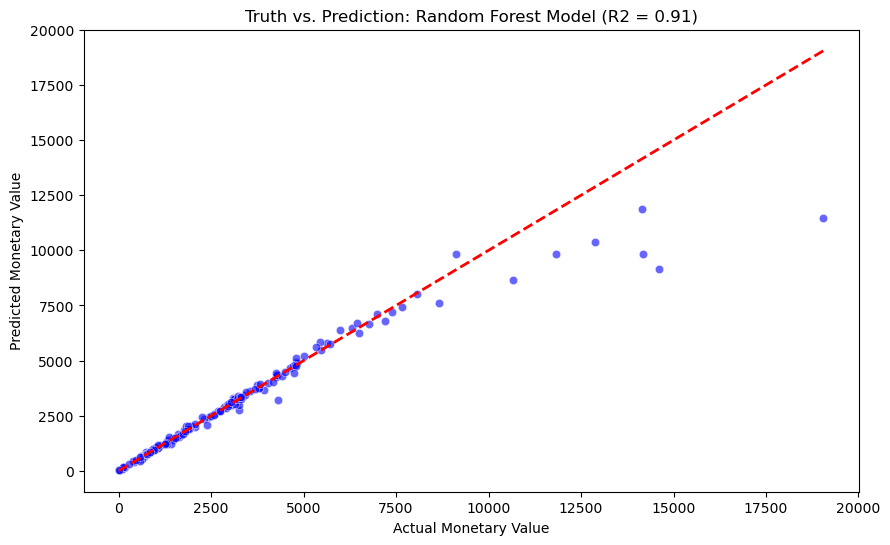

In [20]:
plt.figure(figsize=(10, 6))

# Plot Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')

# Draw a red line showing "Perfect Prediction"
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Monetary Value')
plt.ylabel('Predicted Monetary Value')
plt.title('Truth vs. Prediction: Random Forest Model (R2 = 0.91)')
plt.show()

**Phase 8: The Final Product (The "Leaderboard")**

In [35]:
# 1. Use the model to predict value for EVERY customer in your database
# Note: We must use the same columns we trained on: Recency, Frequency, Avg_Order_Value
rfm['Predicted_LTV'] = model.predict(rfm[['Recency', 'Frequency', 'Avg_Order_Value']])

# 2. Sort the customers by their predicted value
leaderboard = rfm.sort_values(by='Predicted_LTV', ascending=False)

# 3. Create a "Segment" label based on their score
def identify_segment(value):
    if value > leaderboard['Predicted_LTV'].quantile(0.9):
        return "Champion (Top 10%)"
    elif value > leaderboard['Predicted_LTV'].quantile(0.5):
        return "Loyalist"
    else:
        return "At Risk"

leaderboard['Segment'] = leaderboard['Predicted_LTV'].apply(identify_segment)

# --- ADDING NECESSARY COLUMNS ---

# 4. Get the 3 additional columns from the original 'df' 
# We reset the index to ensure Customer ID is a column we can merge on
additional_info = df.groupby('Customer ID').agg({
    'Order Date': 'max', 
    'City': 'first', 
    'Category': lambda x: x.mode()[0]
}).reset_index()

# 5. Merge the 3 columns into the leaderboard
# Since 'leaderboard' currently uses Customer ID as an Index, we use left_index=True
leaderboard = leaderboard.merge(additional_info, left_index=True, right_on='Customer ID', how='left')

# 6. Final cleanup: Ensure all 10 columns are present and in a good order
# Columns: Customer ID, Recency, Frequency, Monetary, Avg_Order_Value, Predicted_LTV, Segment, Order Date, City, Category
leaderboard = leaderboard[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 
                           'Predicted_LTV', 'Segment', 'Order Date', 'City', 'Category']]

# --- NEW ADDITION ENDS HERE ---

# 7. Show the Final Result
print("--- Final Leaderboard (All 10 Columns) ---")
print(leaderboard.head())

--- Final Leaderboard (All 10 Columns) ---
    Customer ID  Recency  Frequency    Monetary  Avg_Order_Value  \
700    SM-20320       80         15  19114.3438      1274.289587   
621    RB-19360       97         18  15117.3390       839.852167   
6      AB-10105       42         20  14473.5710       723.678550   
764    TS-21370       37         15  11891.7510       792.783400   
669    SC-20095      350         22  14142.3340       642.833364   

     Predicted_LTV             Segment Order Date           City  \
700   16037.455318  Champion (Top 10%) 2018-10-12         Monroe   
621   13871.883345  Champion (Top 10%) 2018-09-25         Auburn   
6     13384.801045  Champion (Top 10%) 2018-11-19        Phoenix   
764   12418.426050  Champion (Top 10%) 2018-11-24  New York City   
669   11887.195963  Champion (Top 10%) 2018-01-15        Concord   

            Category  
700  Office Supplies  
621  Office Supplies  
6    Office Supplies  
764  Office Supplies  
669  Office Supplies  


**Phase 9: Saving The File**

In [36]:
# Export to Excel (or CSV)
leaderboard.to_csv("Final_Project_Leaderboard2.csv", index=False)
print("Project Complete! 'Final_Project_Leaderboard2.csv' has been saved.")

Project Complete! 'Final_Project_Leaderboard2.csv' has been saved.


**Phase 10: Load The Trained Model For Deployment**

In [37]:
import pickle

# Save the trained model to a file
with open('clv_rf_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved as 'clv_rf_model.pkl'. You can now move this file to any server!")

Model saved as 'clv_rf_model.pkl'. You can now move this file to any server!
